In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import json
import sqlite3
import requests

from ydata_profiling import ProfileReport

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HP\AppData\Local\Temp\ipykernel_6764\3072787984.py:11: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# Part A : Fundamentals



1. What is Data Analysis?

Data Analysis is the process of collecting, cleaning, organizing, and analyzing data to find useful information and support decision-making.

It helps businesses:

* Understand customer behavior
* Identify patterns and trends
* Improve decision-making
* Build machine learning models


2. Steps of a Data Science Project

Step 1: Problem Understanding

Understand the business problem and project objective.

Step 2: Data Collection

Collect data from different sources such as:

* CSV files
* JSON files
* SQL databases
* APIs

Step 3: Data Cleaning

Clean the dataset by:

* Removing duplicates
* Handling missing values
* Correcting data types

Step 4: Exploratory Data Analysis (EDA)

Analyze data using:

* Statistics
* Charts
* Graphs

Step 5: Feature Engineering

Create useful features from existing data.

Step 6: Model Building

Train machine learning models using cleaned data.

Step 7: Model Evaluation

Check model performance using metrics like:

* Accuracy
* Precision
* Recall
* F1-score

Step 8: Deployment

Deploy the model into a real application.

Step 9: Monitoring

Monitor and improve model performance over time.



3. Machine Learning Problem Statement

Problem Statement

The company wants to predict whether a customer will churn based on:

* Purchase behavior
* Income
* Age
* Spending habits

Objective

Build a machine learning model that predicts:

* Churn = Yes
* Churn = No

Type of Problem

Classification Problem



4. What are Tensors?

A Tensor is a multidimensional data structure used in machine learning and deep learning.

Tensors are used to store and process numerical data efficiently.



Types of Tensors

| Tensor Type | Dimension | Example           |
| ----------- | --------- | ----------------- |
| Scalar      | 0D        | 5                 |
| Vector      | 1D        | [1,2,3]           |
| Matrix      | 2D        | [[1,2],[3,4]]     |
| 3D Tensor   | 3D        | Multiple matrices |



In [2]:
# Load CSV File

df_csv = pd.read_csv(r"C:\Users\HP\Downloads\customer_analysis_dataset.csv")
print(df_csv.head())

   CustomerID     Name  Age  Gender    Income  Purchases Churn
0           1  Felicia   50    Male   34487.0       40.0    No
1           2   Pamela   25  Female  119231.0       28.0    No
2           3  Clayton   42    Male  141648.0       34.0    No
3           4  Heather   24  Female   46706.0       12.0   Yes
4           5  Richard   55  Female   78851.0        NaN   Yes


In [3]:
# Load JSON File

with open(r"C:\Users\HP\Downloads\customers.json") as file:
    data = json.load(file)

print(data)

[{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}, {'id': 2, 'name': 'Ervin Howell', 'username': 'Antonette', 'email': 'Shanna@melissa.tv', 'address': {'street': 'Victor Plains', 'suite': 'Suite 879', 'city': 'Wisokyburgh', 'zipcode': '90566-7771', 'geo': {'lat': '-43.9509', 'lng': '-34.4618'}}, 'phone': '010-692-6593 x09125', 'website': 'anastasia.net', 'company': {'name': 'Deckow-Crist', 'catchPhrase': 'Proactive didactic contingency', 'bs': 'synergize scalable supply-chains'}}, {'id': 3, 'name': 'Clementine Bauch', 'username': 'Samantha', 'email': 'Nathan@yesenia.net', 'address': {'street': 'Douglas Exten

In [4]:
# Connect SQL Database

conn = sqlite3.connect("customer.db")

cursor = conn.cursor()

# Create Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
    CustomerID INTEGER,
    Name TEXT,
    Age INTEGER,
    Income INTEGER
)
""")

# Insert Data
cursor.execute("INSERT INTO customers VALUES (1, 'Dev', 22, 50000)")
cursor.execute("INSERT INTO customers VALUES (2, 'Raj', 25, 60000)")

conn.commit()

# Read Data
query = "SELECT * FROM customers"

df_sql = pd.read_sql(query, conn)

print(df_sql)

    CustomerID Name  Age  Income
0            1  Dev   22   50000
1            2  Raj   25   60000
2            1  Dev   22   50000
3            2  Raj   25   60000
4            1  Dev   22   50000
5            2  Raj   25   60000
6            1  Dev   22   50000
7            2  Raj   25   60000
8            1  Dev   22   50000
9            2  Raj   25   60000
10           1  Dev   22   50000
11           2  Raj   25   60000
12           1  Dev   22   50000
13           2  Raj   25   60000
14           1  Dev   22   50000
15           2  Raj   25   60000


In [5]:
# Fetch Data from API

url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

data = response.json()

df_api = pd.DataFrame(data)

print(df_api.head())

   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera-Crona', 'catchPhrase': 'Mu

In [6]:
print(df_csv.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  200 non-null    int64  
 1   Name        200 non-null    object 
 2   Age         200 non-null    int64  
 3   Gender      200 non-null    object 
 4   Income      183 non-null    float64
 5   Purchases   187 non-null    float64
 6   Churn       200 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 11.1+ KB
None


In [7]:
print(df_csv.describe())

       CustomerID         Age         Income   Purchases
count  200.000000  200.000000     183.000000  187.000000
mean   100.500000   40.730000   83838.049180   26.807487
std     57.879185   13.681117   37893.285002   14.052717
min      1.000000   18.000000   20067.000000    1.000000
25%     50.750000   29.000000   50010.500000   15.500000
50%    100.500000   41.000000   84135.000000   27.000000
75%    150.250000   52.000000  116007.000000   40.000000
max    200.000000   65.000000  149845.000000   50.000000


In [8]:
print(df_csv.isnull().sum())

CustomerID     0
Name           0
Age            0
Gender         0
Income        17
Purchases     13
Churn          0
dtype: int64


In [9]:
print(df_csv.duplicated().sum())

0


In [10]:
df_csv.dropna(inplace=True)

In [11]:
df_csv.fillna(
    df_csv.mean(numeric_only=True),
    inplace=True
)

In [12]:
df_csv['Age'] = df_csv['Age'].astype(int)

df_csv['Purchases'] = df_csv['Purchases'].astype(int)

In [13]:
df_csv.drop(columns=['CustomerID'], inplace=True)

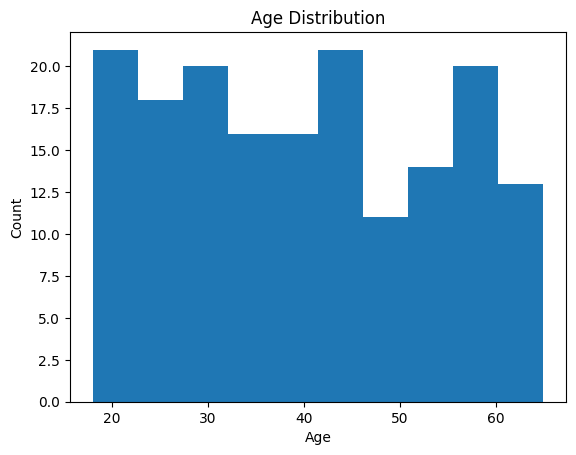

In [14]:
# Age Distribution

plt.hist(df_csv['Age'])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

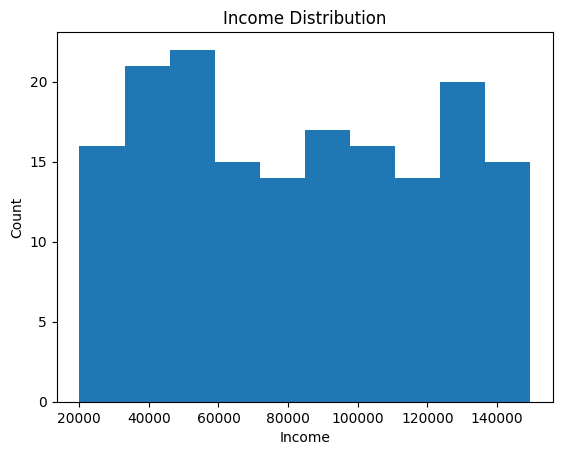

In [15]:
# Income Distribution

plt.hist(df_csv['Income'])

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Count")

plt.show()

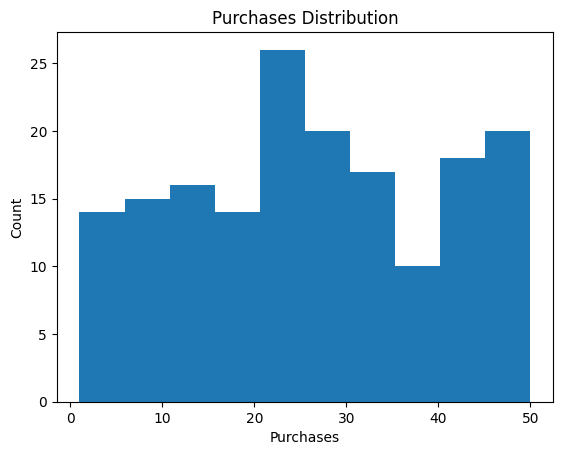

In [16]:
# Purchases Distribution

plt.hist(df_csv['Purchases'])

plt.title("Purchases Distribution")

plt.xlabel("Purchases")

plt.ylabel("Count")

plt.show()

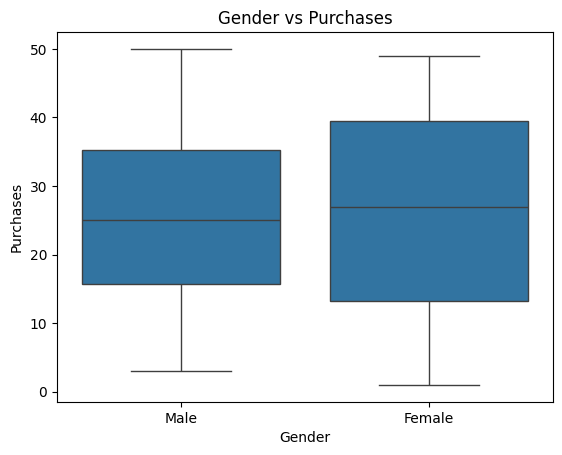

In [17]:
# Gender vs Purchases

sns.boxplot(
    x='Gender',
    y='Purchases',
    data=df_csv
)

plt.title("Gender vs Purchases")

plt.show()

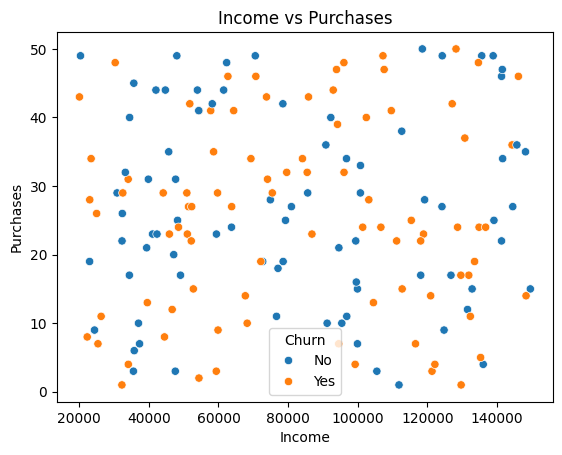

In [18]:
# Income vs Purchases

sns.scatterplot(
    x='Income',
    y='Purchases',
    hue='Churn',
    data=df_csv
)

plt.title("Income vs Purchases")

plt.show()

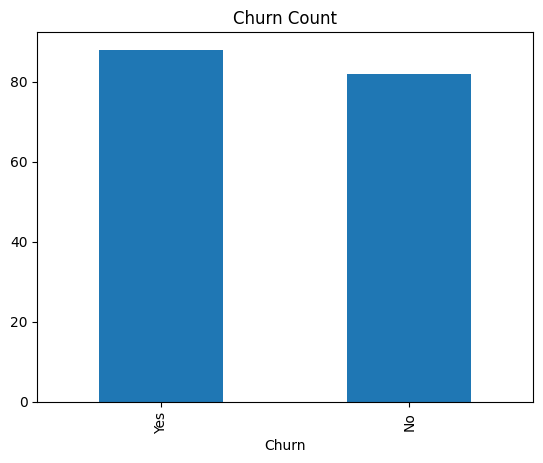

In [19]:
# Churn Count Plot

df_csv['Churn'].value_counts().plot(kind='bar')

plt.title("Churn Count")

plt.show()

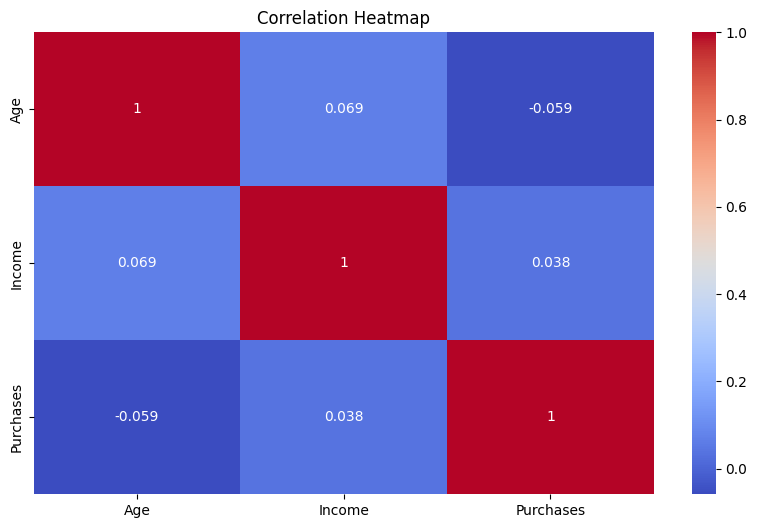

In [20]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df_csv.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

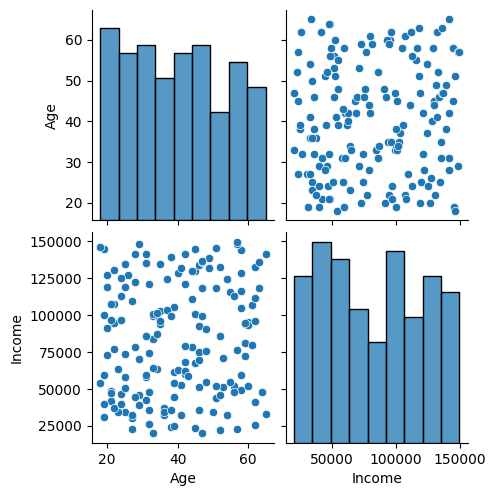

In [24]:
# Pair Plot

sns.pairplot(
    df_csv[['Age','Income']]
)

plt.show()